Prototipo Projeto CAR

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
from load_data import GeoDataLoader

#carrega dados
files = {
        "car": "dados/PARA/CAR/AREA_IMOVEL_1.shp",
        "municipios": "dados/PARA/Municipios/PA_Municipios_2023.shp",
        "uf": "dados/PARA/UF/PA_UF_2023.shp",
}

datasets = GeoDataLoader().load_all(files)

gdf,g_m,uf=datasets["car"],datasets["municipios"],datasets["uf"]

print(gdf.columns)





Loading car from dados/PARA/CAR/AREA_IMOVEL_1.shp...
Loading municipios from dados/PARA/Municipios/PA_Municipios_2023.shp...
Loading uf from dados/PARA/UF/PA_UF_2023.shp...
Index(['cod_tema', 'nom_tema', 'cod_imovel', 'mod_fiscal', 'num_area',
       'ind_status', 'ind_tipo', 'des_condic', 'municipio', 'cod_estado',
       'dat_criaca', 'dat_atuali', 'geometry'],
      dtype='object')


Propiedades que se intercedem:

In [2]:
print(g_m)

      CD_MUN              NM_MUN  CD_RGI      NM_RGI CD_RGINT   NM_RGINT  \
0    1500107          Abaetetuba  150003  Abaetetuba     1501      Belém   
1    1500131     Abel Figueiredo  150009      Marabá     1503     Marabá   
2    1500206               Acará  150001       Belém     1501      Belém   
3    1500305                Afuá  150020      Breves     1507     Breves   
4    1500347  Água Azul do Norte  150014    Xinguara     1504   Redenção   
..       ...                 ...     ...         ...      ...        ...   
139  1508159              Uruará  150018    Altamira     1506   Altamira   
140  1508209               Vigia  150001       Belém     1501      Belém   
141  1508308               Viseu  150005    Bragança     1502  Castanhal   
142  1508357    Vitória do Xingu  150018    Altamira     1506   Altamira   
143  1508407            Xinguara  150014    Xinguara     1504   Redenção   

    CD_UF NM_UF CD_REGIAO NM_REGIAO CD_CONCURB  NM_CONCURB   AREA_KM2  \
0      15  Par

/tmp/ipykernel_2405018/1436836345.py:52: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend(["Propriedades", "Áreas de Interseção"], loc="upper right", fontsize=10)


<Figure size 300x300 with 0 Axes>

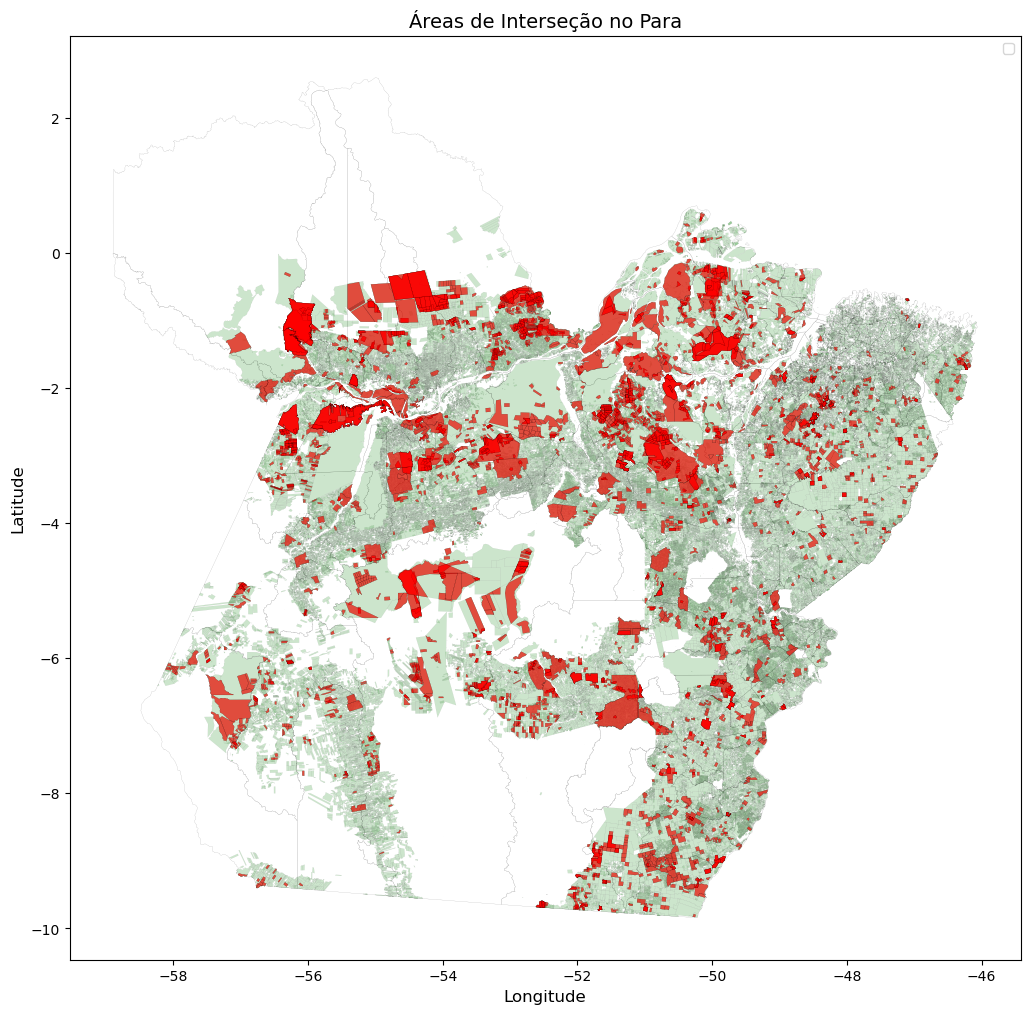

,geometry,property_i,uc_i
0,"POLYGON ((-51.992 -1.4068, -52.0061 -1.4107, -...",PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7,PA-1500503-9BCDEF19835F4A709056FCBC709847B2
1,"POLYGON ((-52.1336 -1.2866, -52.1151 -1.2859, ...",PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7,PA-1500503-430FACD5D84F4C8591B17BBBFCB94A80
2,"POLYGON ((-52.08575 -1.27369, -52.08038 -1.272...",PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7,PA-1500503-D813D36188744EC5918FC84D4F56653A
3,"POLYGON ((-51.98617 -1.28415, -51.9253 -1.2993...",PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7,PA-1500503-8E9DFB93B2E441ACA1FB85E312C00178
4,"POLYGON ((-52.03367 -1.32308, -52.06681 -1.291...",PA-1500503-1B415D59863B470E9EFB4BE2F150E6D7,PA-1500503-9B5290399E79475A92960604141F01F3


In [5]:

# Criar um índice espacial para melhorar a busca por interseções
sindex = gdf.sindex

# Definir um valor mínimo de área para considerar as interseções (em unidades do CRS, por exemplo, graus quadrados)
min_area = 0.001  # Ajuste este valor de acordo com o seu caso de uso

# Encontrar geometrias que se interceptam
intersecting_geometries = []  # Lista para armazenar as geometrias de interseção
intersecting_ids = []  # Lista para armazenar os IDs das propriedades que se intersectam
intersecting_ids2 = []  # Lista para armazenar os IDs das propriedades que se intersectam

# Iterar sobre cada geometria e verificar as interseções
for idx, geom in gdf.geometry.items():
    # Encontrar possíveis interseções baseadas nos limites das geometrias
    # Essa parte é crucial, permite processar dataset grandes agilizando verificação de overlap com index espacial O(n^2) -> O(n log n)
    possible_matches = list(sindex.intersection(geom.bounds))
    for match in possible_matches:
     try:
        intersection = geom.intersection(gdf.geometry.iloc[match].buffer(0))
        if idx != match and geom.intersects(gdf.geometry.iloc[match]):
            # Realizar a interseção das geometrias e usar buffer(0) para corrigir problemas de precisão
            
                # Verificar se a interseção não é vazia e se sua área é maior que o limite mínimo
                if not intersection.is_empty and intersection.area >= min_area:
                    intersecting_geometries.append(intersection)
                    intersecting_ids.append(gdf.iloc[idx]["cod_imovel"]) 
                    intersecting_ids2.append(gdf.iloc[match]["cod_imovel"])  # Armazenar os IDs das propriedades que se intersectam
     except:
                print("")
# Criar um GeoDataFrame para as áreas de interseção
intersecting_gdf = gpd.GeoDataFrame(geometry=intersecting_geometries, crs=gdf.crs)
intersecting_gdf['property_i'] = intersecting_ids  # Armazenar o par de IDs das propriedades
intersecting_gdf['uc_i'] = intersecting_ids2  # hack para que possamos usar a mesma pipeline de interseção car_uc

# Simplificar as geometrias das interseções para visualização mais detalhada
intersecting_gdf.geometry = intersecting_gdf.geometry.simplify(tolerance=0.00001, preserve_topology=True)

# Plotar o mapa
plt.figure(figsize=(5, 5), dpi=60)  # Definir uma alta resolução (DPI) para detalhes finos

# Criar o eixo de plotagem
ax = gdf.plot(color='green', edgecolor='black', alpha=0.4, linewidth=0.1, label="Propriedades", figsize=(20,12))

g_m.plot(ax=ax, color='white', edgecolor='black', alpha=0.5, linewidth=0.1, label="Municípios")
# Sobrepor as áreas de interseção no mesmo gráfico
intersecting_gdf.plot(ax=ax, color='red', alpha=0.4, edgecolor='black', linewidth=0.1)

# Adicionar título e rótulos aos eixos
plt.title("Áreas de Interseção no Para", fontsize=14)
plt.xlabel("Longitude", fontsize=12)
plt.ylabel("Latitude", fontsize=12)
plt.legend(["Propriedades", "Áreas de Interseção"], loc="upper right", fontsize=10)

# Mostrar o gráfico
plt.show()

# Opcional: inspecionar o GeoDataFrame com os dados das interseções
intersecting_gdf.head()



A partir desses dados de interseção podemos:

*   Quantificar o numero / area total irregular por região / municipio e cruzar isso com dados de desmatamento. Seria possivel ate mapear o desmatamento com dados geograficos e cruzar com os da interseção identificando as areas de interseção desmatada.
*   Indetificar casos especificos com grandes areas irregulares.
*   Adicionar os dados sobre hidrografia, reservas etc, para identificar também esse tipo de irregularidade.




In [6]:
intersecting_gdf.to_file("Resultados/car_car_intersect/shapes_intersect.shp", driver='ESRI Shapefile')

print(intersecting_gdf.columns)

Index(['geometry', 'property_i', 'uc_i'], dtype='object')


In [7]:
# Calculate the area of each property
gdf['area'] = gdf.geometry.area

# Create a spatial index for the contested regions
spatial_index = intersecting_gdf.sindex

# Initialize a dictionary to store intersection areas for each property
intersection_area_by_id = {}

# Iterate over each property and calculate intersections with contested regions
for idx, row in gdf.iterrows():
    print(idx)
    # Query the spatial index to find potential intersections
    potential_intersections_idx = list(spatial_index.intersection(row.geometry.bounds))
    potential_intersections = intersecting_gdf.iloc[potential_intersections_idx]

    # Calculate the total intersection area for the current property
    total_intersection_area = sum(
        row.geometry.intersection(contested_row.geometry).area
        for _, contested_row in potential_intersections.iterrows()
    )

    # Store the total intersection area for the current property
    intersection_area_by_id[idx] = total_intersection_area

# Add the intersection area as a new column to the original GeoDataFrame
gdf['intersection_area'] = gdf.index.map(intersection_area_by_id).fillna(0)

# Calculate the overlap percentage (intersection area / total area)
gdf['overlap_percentage'] = (gdf['intersection_area'] / gdf['area']) * 100

# Ensure overlap percentage is capped at 100%
gdf['overlap_percentage'] = gdf['overlap_percentage'].clip(upper=100)

# Plot the histogram of overlap percentages
plt.figure(figsize=(10, 6))  # Adjust figure size as needed
plt.hist(gdf['overlap_percentage'], bins=20, edgecolor='black')  # Adjust bins as needed
plt.title('Percentage of CAR Property in Contested Territory')
plt.xlabel('Overlap Percentage')
plt.ylabel('Frequency')
plt.yscale("log")
plt.grid(True)
plt.show()



/tmp/ipykernel_2405018/479483952.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['area'] = gdf.geometry.area


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
27

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Define the color palette for each group
colors = {
    "Analisado": 'tab:blue',
    "Cancelado": 'tab:orange',
    "Em analise": 'tab:green'
}

grouped_conditions = {
    "Analisado": gdf[gdf['des_condic'].str.startswith("Analisado")],
    "Cancelado": gdf[gdf['des_condic'].str.startswith("Cancelado")],
    "Em analise": gdf[~gdf['des_condic'].str.startswith(("Analisado", "Cancelado"))]
}

# Calculate histograms for each group
hist_data = {}
bin_edges = None
for group_name, group_data in grouped_conditions.items():
    hist_data[group_name], bin_edges = np.histogram(group_data['overlap_percentage'], bins=20, density=True)

# Set up bar positions for side-by-side display
width = (bin_edges[1] - bin_edges[0]) * 0.3  # Adjust width of bars
x_positions = [bin_edges[:-1] + i * width for i in range(len(grouped_conditions))]

# Plotting
plt.figure(figsize=(10, 6))  # Adjust figure size as needed

# Plot each group
for i, (group_name, group_data) in enumerate(grouped_conditions.items()):
    plt.bar(x_positions[i], hist_data[group_name], width=width, alpha=0.6, label=group_name, edgecolor='black', color=colors[group_name])


plt.xlabel('Porcetagem do Car sobreposto')
plt.ylabel('Frequencia Relativa')
#plt.yscale("log")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()


In [ ]:
import pandas as pd

print(gdf.columns)
# Define the grouping based on 'des_condic' as provided
grouped_conditions = {
    "Analisado": gdf[gdf['des_condic'].str.startswith("Analisado")],
    "Cancelado": gdf[gdf['des_condic'].str.startswith("Cancelado")],
    "Em analise": gdf[~gdf['des_condic'].str.startswith(("Analisado", "Cancelado"))]
}

# Initialize a dictionary to store the stats for each group
group_stats = {}

# Iterate over each group to calculate the stats
for group_name, group_data in grouped_conditions.items():
    total_area = group_data['area'].sum()  # Total area
    total_overlap_area = group_data['intersection_area'].sum()  # Total overlapped area
    num_cars = len(group_data)  # Number of CARs

    # Store the computed stats in the dictionary
    group_stats[group_name] = {
        'Area Total': total_area,
        'Area Sobreposta': total_overlap_area * 0.5,
        'Numero de CARs': num_cars,
    }

# Print the stats for each group
for group_name, stats in group_stats.items():
    print(f"{group_name}:")
    for stat_name, stat_value in stats.items():
        if stat_name == 'Numero de CARs':
            print(f"  {stat_name}: {stat_value}")
        else:
            print(f"  {stat_name}: {100 * 111 * 110.8 * stat_value / 1000000:.1f} mHa")
    print("\n")


In [ ]:
from shapely.ops import unary_union

# Standardize and sort the `des_condic` column in `intersecting_with_info_sorted`
intersecting_with_info_sorted['des_condic'] = intersecting_with_info_sorted['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Standardize and sort the `des_condic` column for CAR geometries
gdf['des_condic'] = gdf['des_condic'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Create dictionaries for combined geometries
categorys = {}  # For intersections
car_geometries_by_condition = {}  # For CAR geometries

# Generate combined geometries for each category from `intersecting_with_info_sorted`
for category in intersecting_with_info_sorted['des_condic'].unique():
    print(f"Processing intersection geometries for category: {category}")
    category_geometries = intersecting_with_info_sorted[
        intersecting_with_info_sorted['des_condic'] == category
    ].geometry_x
    categorys[category] = unary_union(category_geometries)

# Generate combined geometries for CAR, grouped by the same conditions
for category in gdf['des_condic'].unique():
    print(f"Processing CAR geometries for category: {category}")
    car_geometries = gdf[gdf['des_condic'] == category].geometry
    car_geometries_by_condition[category] = unary_union(car_geometries)



# Check results
print("Combined geometries for intersections:", categorys)


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely.ops import unary_union
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Normalize the Overlap Percentage to 0-1 for colormap
norm = Normalize(vmin=condition_overlap_df["Overlap Percentage"].min(), 
                 vmax=condition_overlap_df["Overlap Percentage"].max())
cmap = cm.get_cmap("viridis")

g_m = datasets["municipios"]
print(categorys.keys())

# Prepare the municipality GeoDataFrame
g_m["Cidade"] = g_m["NM_MUN"]

# Drop Color column from g_m if it exists to avoid conflicts
if "Color" in g_m.columns:
    g_m = g_m.drop(columns=["Color"])

# Calculate areas of intersection with combined category geometries
area_data = []
for k, city_row in g_m.iterrows():
    city_name = city_row["Cidade"]
    city_geom = city_row["geometry"]
    
    for category, category_geom in categorys.items():
        if category == "CAR":  # Skip "CAR" top-level key for intersections
            continue

        # Calculate intersection
        intersection = city_geom.intersection(category_geom)
        # Compute area of intersection
        intersection_area = intersection.area if not intersection.is_empty else 0
        
        # Compute total CAR area for the same category
        car_area_for_category = city_geom.intersection(car_geometries_by_condition[category]).area 
        
        # Store results
        area_data.append({
            "Cidade": city_name,
            "Category": category,
            "Total CAR Area in Category": car_area_for_category,
            "City Area": city_geom.area,
            "Intersection Area": intersection_area
        })

# Convert area data into a DataFrame
area_df = pd.DataFrame(area_data)

print(area_df)


In [ ]:
# Normalize Intersection Area by the Total CAR Area in the respective category
area_df["Percentage Relative to CAR"] = area_df.apply(
    lambda row: (row["Intersection Area"] / row["Total CAR Area in Category"]) * 100 
    if row["Total CAR Area in Category"] > 0 else None,
    axis=1
)

# Merge the normalized percentages back into the GeoDataFrame
g_m["Cidade"] = g_m["NM_MUN"]
merged_g_m = g_m.merge(
    area_df[["Cidade", "Category", "Percentage Relative to CAR"]],
    on="Cidade",
    how="left"
)

# Get unique categories to plot (excluding CAR as needed)
categories = area_df["Category"].unique()

# Prepare the plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(categories),
    figsize=(20, 8),
    dpi=100,
    constrained_layout=True
)

# Ensure axes is iterable for single-category cases
if len(categories) == 1:
    axes = [axes]

# Normalize percentages for colormap
norm = Normalize(vmin=0, vmax=100)
cmap = cm.get_cmap("coolwarm")  # Update as per matplotlib version if needed

# Generate spatial plots for each category
for ax, category in zip(axes, categories):
    # Map normalized percentages to colors
    category_data = merged_g_m[merged_g_m["Category"] == category]
    category_data[f"Color {category}"] = category_data["Percentage Relative to CAR"].apply(
        lambda x: cmap(x / 100) if pd.notnull(x) else (0, 0, 0, 0)
    )

    # Plot base map
    uf.plot(ax=ax, color="white", edgecolor="black", linewidth=1, alpha=1)

    # Plot cities with gradient colors
    category_data.plot(
        ax=ax,
        color=category_data[f"Color {category}"],
        edgecolor="black",
        linewidth=0.2,
        alpha=1
    )

    # Set title and labels
    ax.set_title(f"Condição: {category}", fontsize=14, pad=10)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

# Add a single colorbar for all subplots
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([0, 100])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.02, pad=0.1)
cbar.set_label("Area de Overlap (% Relativa a area total dos registros)", fontsize=12)

# Display the plots
#plt.suptitle("Colored Spatial Plots by Category (% Relative to Total CAR Area in Category)", fontsize=16, y=1.02)
plt.show()




In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm

# Normalize Intersection Area by the Total CAR Area in the respective category
area_df["Percentage Relative to CAR"] = area_df.apply(
    lambda row: (row["Intersection Area"] / row["Total CAR Area in Category"]) * 100 
    if row["Total CAR Area in Category"] > 0 else None,
    axis=1
)

# Merge the normalized percentages back into the GeoDataFrame
g_m["Cidade"] = g_m["NM_MUN"]
merged_g_m = g_m.merge(
    area_df[["Cidade", "Category", "Intersection Area"]],
    on="Cidade",
    how="left"
)

# Get unique categories to plot (excluding CAR as needed)
categories = area_df["Category"].unique()

# Prepare the plot
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(categories),
    figsize=(20, 8),
    dpi=100,
    constrained_layout=True
)
merged_g_m["Intersection Area"]= merged_g_m["Intersection Area"]*110*100*100/1e6
# Ensure axes is iterable for single-category cases
if len(categories) == 1:
    axes = [axes]

# Normalize Intersection Area for colormap
norm = Normalize(vmin=merged_g_m["Intersection Area"].min(), 
                 vmax=merged_g_m["Intersection Area"].max())
cmap = cm.get_cmap("coolwarm")  # Update as per matplotlib version if needed

# Generate spatial plots for each category
for ax, category in zip(axes, categories):
    # Filter the data for the current category
    category_data = merged_g_m[merged_g_m["Category"] == category]
    
    # Map intersection area to colors (using actual units)
    category_data[f"Color {category}"] = category_data["Intersection Area"].apply(
        lambda x: cmap((x - merged_g_m["Intersection Area"].min()) / 
                       (merged_g_m["Intersection Area"].max() - merged_g_m["Intersection Area"].min())) 
        if pd.notnull(x) else (0, 0, 0, 0)
    )

    # Plot base map
    uf.plot(ax=ax, color="white", edgecolor="black", linewidth=1, alpha=1)

    # Plot cities with gradient colors based on intersection area
    category_data.plot(
        ax=ax,
        color=category_data[f"Color {category}"],
        edgecolor="black",
        linewidth=0.2,
        alpha=1
    )

    # Set title and labels
    ax.set_title(f"Condição: {category}", fontsize=14, pad=10)
    ax.set_xlabel("Longitude", fontsize=10)
    ax.set_ylabel("Latitude", fontsize=10)
    ax.grid(color="gray", linestyle="--", linewidth=0.5, alpha=0.7)

# Add a single colorbar for all subplots (for intersection area)
sm_intersection_area = ScalarMappable(cmap=cmap, norm=norm)
sm_intersection_area.set_array([merged_g_m["Intersection Area"].min(), merged_g_m["Intersection Area"].max()])
cbar_intersection_area = fig.colorbar(sm_intersection_area, ax=axes, orientation="horizontal", fraction=0.02, pad=0.1)
cbar_intersection_area.set_label("Área de Interseção (m.Ha)", fontsize=12)

# Display the plots
plt.show()




In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.cm as cm
from unidecode import unidecode  # Import unidecode to remove accents

# Load CAR data
file1 = "Resultados/resultados_por_car.csv"
df_car = pd.read_csv(file1)
g_m= datasets["municipios"]
# Add city name column to GeoDataFrame (g_m)
g_m["cidade"] = g_m["NM_MUN"]

# Clean and standardize 'cond' column in df_car
df_car["cond"] = df_car['cond'].apply(
    lambda x: "Analisado" if x.startswith("Analisado") else (
        "Cancelado" if x.startswith("Cancelado") else "Em analise"
    )
)

# Normalize city names to lowercase and remove accents for case-insensitive matching
df_car["cidade"] = df_car["cidade"].apply(lambda x: unidecode(x.strip().lower()))
g_m["cidade"] = g_m["cidade"].apply(lambda x: unidecode(x.strip().lower()))

# Calculate percentages for each condition per city
city_status = df_car.groupby("cidade")["cond"].value_counts(normalize=True).unstack(fill_value=0) * 100
city_status.reset_index(inplace=True)

# Merge percentages with GeoDataFrame
g_m = g_m.merge(city_status, on="cidade", how="left")

# Define conditions and colormap
conditions = ["Analisado", "Cancelado", "Em analise"]
cmap = cm.get_cmap("viridis")

# Prepare the plot with subplots
fig, axes = plt.subplots(
    nrows=1,
    ncols=len(conditions),
    figsize=(15, 8),
    dpi=100,
    constrained_layout=True
)

if len(conditions) == 1:
    axes = [axes]  # Ensure axes is iterable for a single condition

# Plot each condition in a subplot
for ax, cond in zip(axes, conditions):
    # Normalize values for color scale
    norm = Normalize(vmin=g_m[cond].min(), vmax=g_m[cond].max())

    # Plot base map
    g_m.plot(ax=ax, color="white", edgecolor="black", linewidth=0.5)

    # Plot cities with color gradient
    g_m.plot(
        ax=ax,
        color=g_m[cond].apply(
            lambda x: cmap(norm(x)) if pd.notnull(x) else (0.9, 0.9, 0.9, 1)  # Light gray for missing data
        ),
        edgecolor="black",
        linewidth=0.5
    )

    # Add title and labels for each subplot
    ax.set_title(f"Percentual de {cond}", fontsize=16, pad=10)
    ax.set_xlabel("Longitude", fontsize=12)
    ax.set_ylabel("Latitude", fontsize=12)

# Add a single colorbar for all subplots
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, orientation="horizontal", fraction=0.02, pad=0.1)
cbar.set_label("Percentual (%)", fontsize=12)

# Display the plot
plt.show()
